# 21 - Intermediate Fusion Front-Only 7-Class

**Dataset:** Front-only 7-Class
**3 Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import IntermediateFusion
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)})")

Device: cuda
GPU: Tesla T4)


In [2]:
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly" / "7class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 7
EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]

print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/7class


In [3]:
print("Loading multimodal data...")
def load_dataloaders(dataset_dir, batch_size=32):
    train_ds = EmotionMultimodalDataset(
        dataset_dir / "X_train_images.npy", dataset_dir / "X_train_landmarks.npy", dataset_dir / "y_train.npy")
    val_ds = EmotionMultimodalDataset(
        dataset_dir / "X_val_images.npy", dataset_dir / "X_val_landmarks.npy", dataset_dir / "y_val.npy")
    test_ds = EmotionMultimodalDataset(
        dataset_dir / "X_test_images.npy", dataset_dir / "X_test_landmarks.npy", dataset_dir / "y_test.npy")
    train_l = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_l = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_l = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return train_l, val_l, test_l

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Loading multimodal data...


Train: 5348 | Val: 707 | Test: 1036
     neutral: 4192
       happy: 660
         sad: 382
       angry: 42
     fearful: 7
   disgusted: 16
   surprised: 49


## Skenario B1: Baseline

Model parameters: 52,466,471

Training INTERMEDIATE B1 - Baseline (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.4758     0.4792     1.0560    0.9378   0.1383   0.000100  (32.4s)


     2      0.8554     0.7762     0.5853    0.9364   0.1382   0.000100  (32.1s)


     3      0.7425     0.7835     0.4754    0.9378   0.1383   0.000100  (32.0s)


     4      0.6716     0.7923     0.3855    0.9378   0.1383   0.000100  (32.0s)


...

    27      0.3157     0.8925     0.4099    0.8982   0.2151   0.000050  (31.7s)


    28      0.2968     0.8962     0.4128    0.8897   0.2141   0.000050  (31.8s)


    29      0.2942     0.8981     0.4979    0.8331   0.1900   0.000050  (31.8s)


    30      0.2934     0.8981     0.3884    0.9151   0.2313   0.000050  (31.7s)


    31      0.2780     0.9041     0.3427    0.9364   0.2574   0.000050  (31.8s)

Early stopping at epoch 31. Best epoch: 16 (val_f1=0.2622)

Best: epoch 16, val_acc=0.9434, val_f1=0.2622
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/7class/intermediate_b1.pth


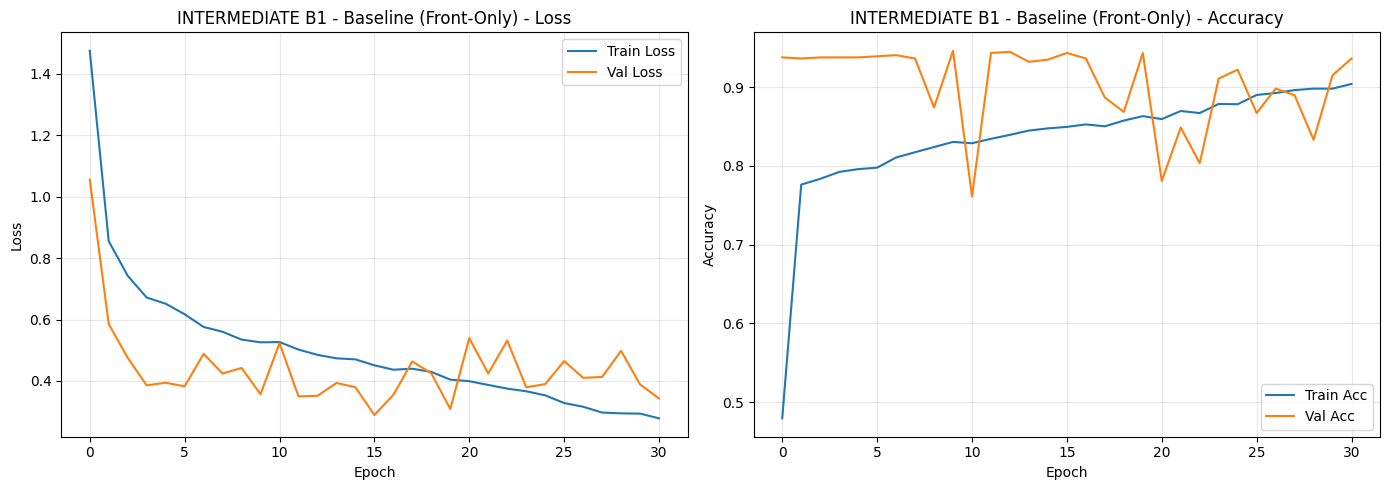

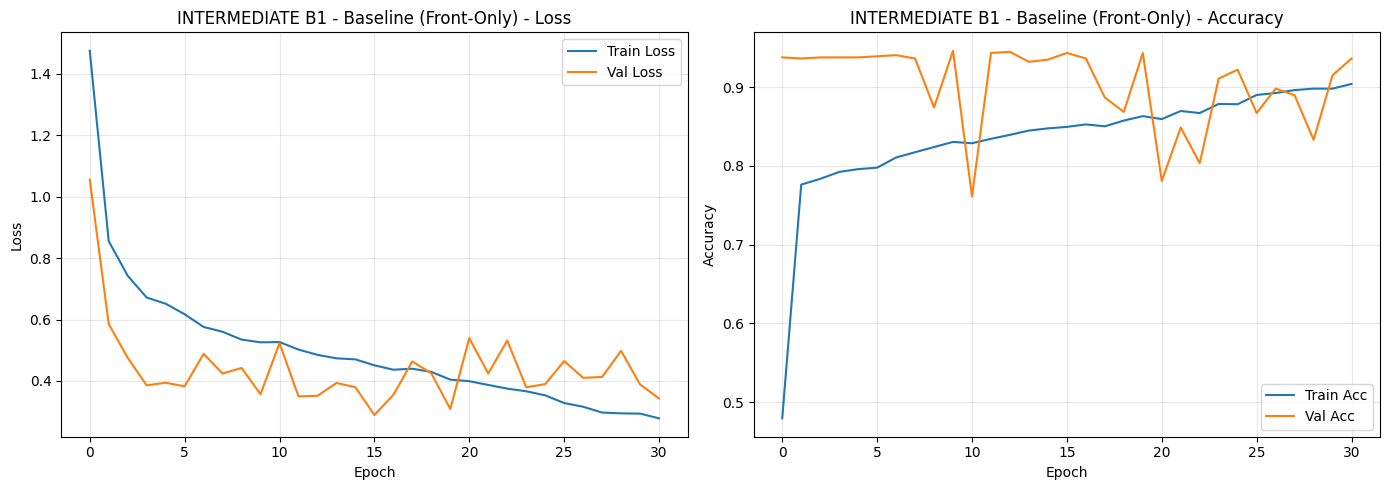

In [4]:
# B1: Baseline
criterion = nn.CrossEntropyLoss()

model = IntermediateFusion(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining INTERMEDIATE B1 - Baseline (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_b1.pth"))

plot_training_history(history, "INTERMEDIATE B1 - Baseline (Front-Only)")

EVALUASI B1 - BASELINE


Test Loss: 0.3137
Test Accuracy: 0.9141
Test Macro F1: 0.1371
Test Weighted F1: 0.9090

Classification Report:
              precision    recall  f1-score   support

     neutral       0.95      0.97      0.96       981
       happy       0.00      0.00      0.00        10
         sad       0.00      0.00      0.00        29
       angry       0.00      0.00      0.00        10
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         2

    accuracy                           0.91      1036
   macro avg       0.14      0.14      0.14      1036
weighted avg       0.90      0.91      0.91      1036



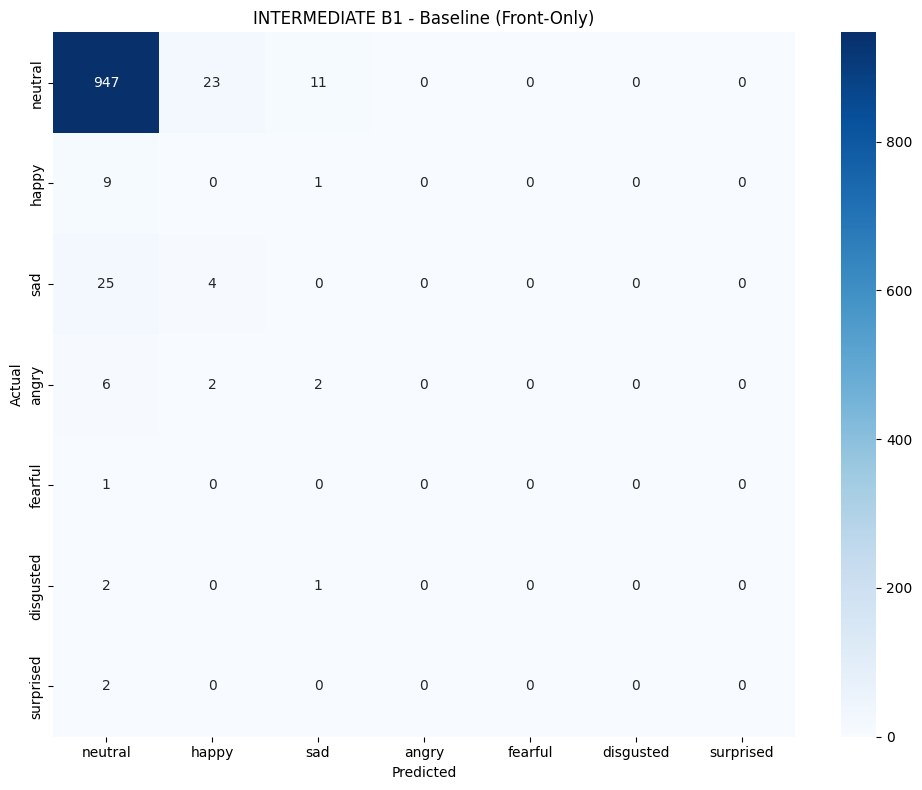

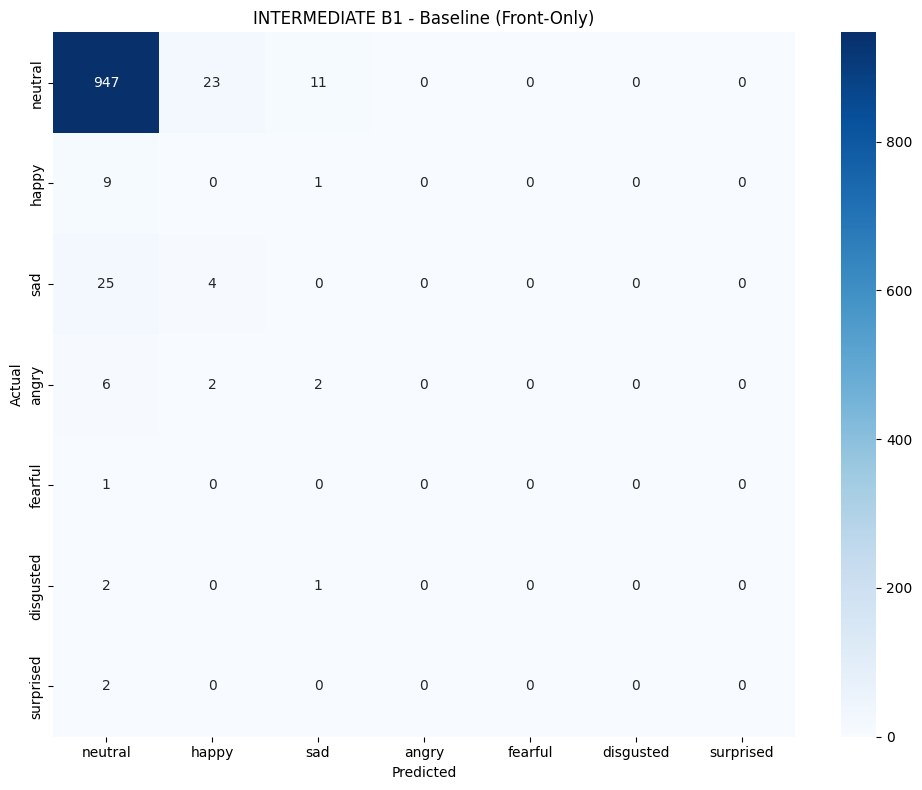

In [5]:
# Evaluate B1
model.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_b1.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model, test_loader, criterion, device, "fusion", EMOTIONS)
plot_confusion_matrix(results_b1["confusion_matrix"], "INTERMEDIATE B1 - Baseline (Front-Only)", EMOTIONS)

## Skenario B2: Class Weights

Class weights: None


Model parameters: 52,466,471

Training INTERMEDIATE B2 - Class Weights (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.3136     0.6004     1.1274    0.9349   0.1381   0.000100  (31.7s)


     2      0.8342     0.7810     0.8900    0.8091   0.1305   0.000100  (31.7s)


     3      0.7315     0.7833     0.8209    0.6506   0.1164   0.000100  (31.7s)


...

    18      0.4250     0.8586     0.6001    0.6902   0.1892   0.000050  (31.8s)


    19      0.4117     0.8635     0.6061    0.6902   0.1781   0.000050  (31.8s)


    20      0.4063     0.8642     0.6893    0.6450   0.1767   0.000050  (31.8s)


    21      0.3973     0.8684     0.6441    0.6549   0.1660   0.000050  (31.8s)


    22      0.3875     0.8695     0.6430    0.6648   0.1796   0.000050  (31.9s)

Early stopping at epoch 22. Best epoch: 7 (val_f1=0.1949)

Best: epoch 7, val_acc=0.6775, val_f1=0.1949
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/7class/intermediate_b2.pth


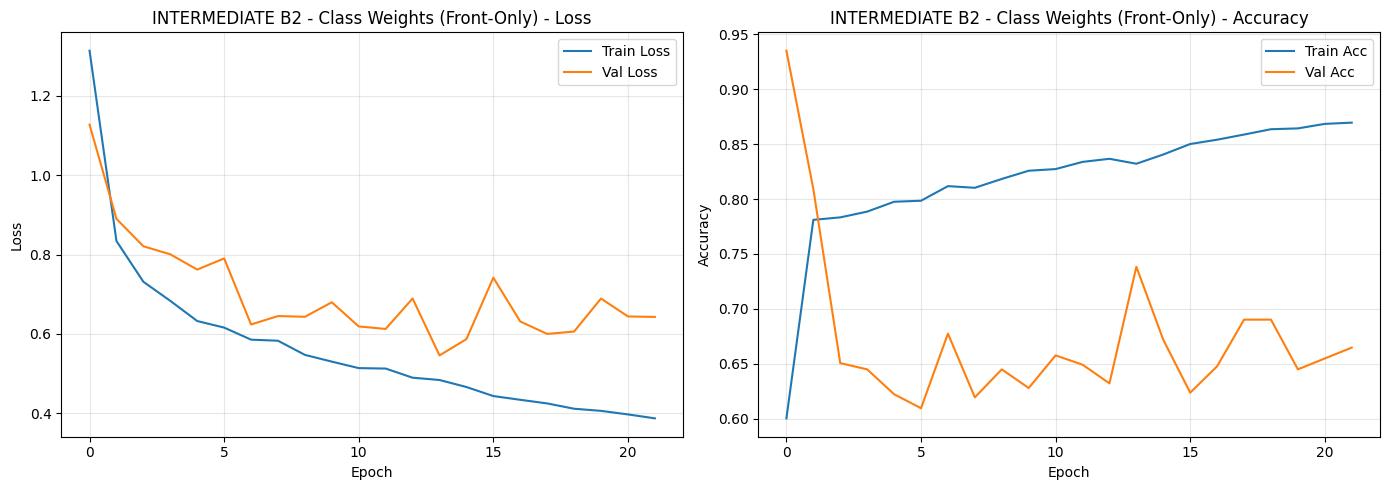

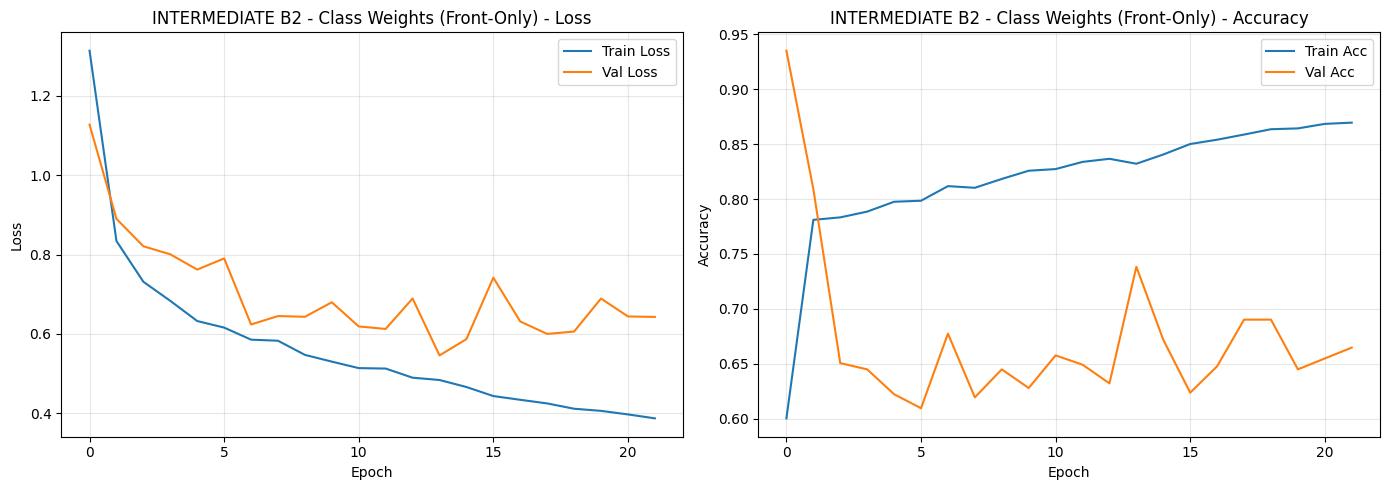

In [6]:
# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")
criterion = nn.CrossEntropyLoss(weight=weights)

model = IntermediateFusion(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining INTERMEDIATE B2 - Class Weights (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_b2.pth"))

plot_training_history(history, "INTERMEDIATE B2 - Class Weights (Front-Only)")

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 0.4909
Test Accuracy: 0.8494
Test Macro F1: 0.1355
Test Weighted F1: 0.8851

Classification Report:
              precision    recall  f1-score   support

     neutral       0.98      0.90      0.93       981
       happy       0.01      0.10      0.01        10
         sad       0.00      0.00      0.00        29
       angry       0.00      0.00      0.00        10
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         2

    accuracy                           0.85      1036
   macro avg       0.14      0.14      0.14      1036
weighted avg       0.92      0.85      0.89      1036



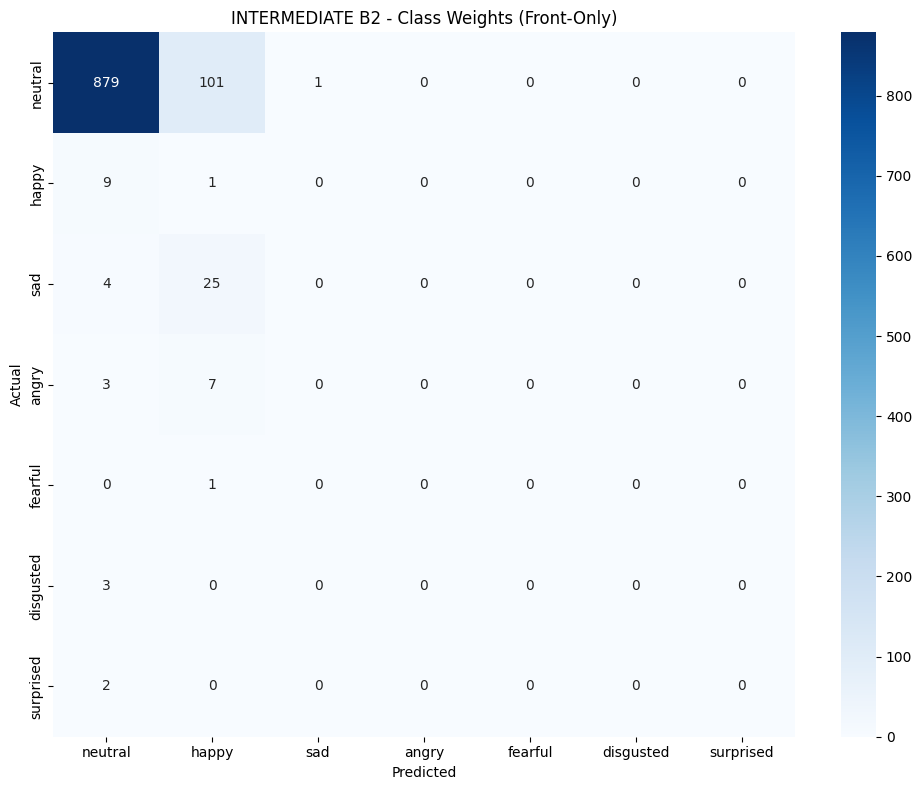

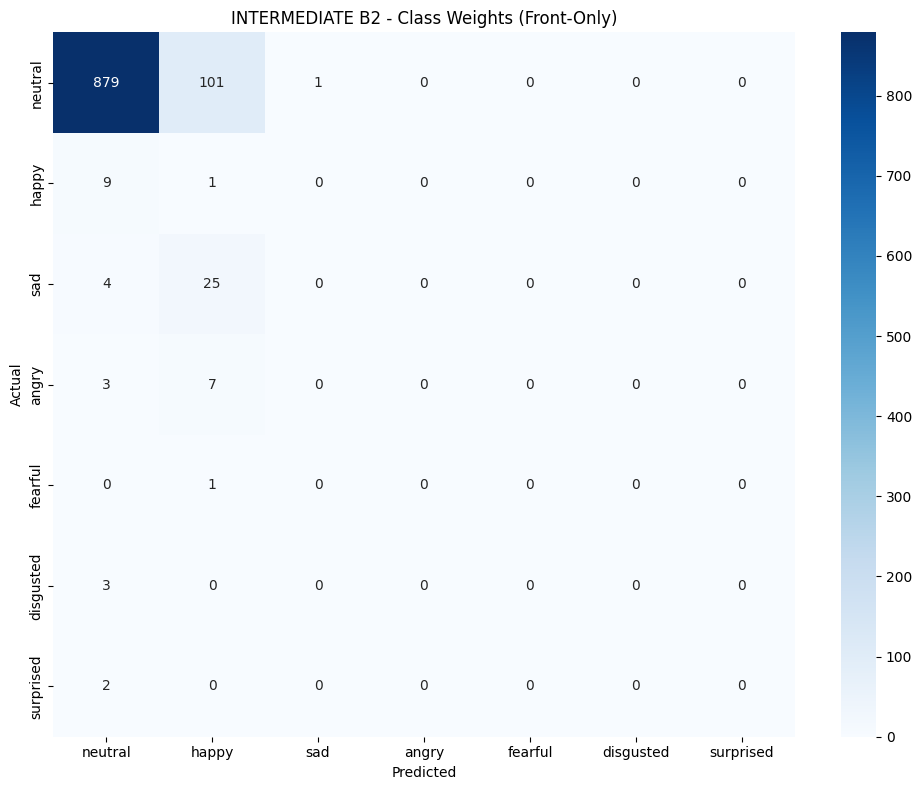

In [7]:
# Evaluate B2
model.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_b2.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model, test_loader, criterion, device, "fusion", EMOTIONS)
plot_confusion_matrix(results_b2["confusion_matrix"], "INTERMEDIATE B2 - Class Weights (Front-Only)", EMOTIONS)

## Skenario B3: Class Weights + Augmentasi

Train: 5834 | Val: 707 | Test: 1036
     neutral: 4192
       happy: 660
         sad: 382
       angry: 150
     fearful: 150
   disgusted: 150
   surprised: 150
Augmented class weights: None


Model parameters: 52,466,471

Training INTERMEDIATE B3 - Weights + Augmentasi (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.4695     0.5113     1.0577    0.9378   0.1383   0.000100  (35.4s)


     2      1.0259     0.7137     0.5580    0.9378   0.1383   0.000100  (37.1s)


     3      0.9239     0.7261     0.4792    0.9378   0.1383   0.000100  (37.3s)


...

    27      0.2800     0.9020     0.4039    0.8953   0.2191   0.000050  (35.5s)


    28      0.2732     0.9057     0.4107    0.8784   0.2167   0.000050  (35.7s)


    29      0.2529     0.9097     0.6118    0.7199   0.1717   0.000050  (35.4s)


    30      0.2555     0.9104     0.6041    0.7397   0.1693   0.000050  (35.4s)


    31      0.2415     0.9203     0.7288    0.6733   0.1627   0.000050  (35.5s)

Early stopping at epoch 31. Best epoch: 16 (val_f1=0.2674)

Best: epoch 16, val_acc=0.9448, val_f1=0.2674
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/7class/intermediate_b3.pth


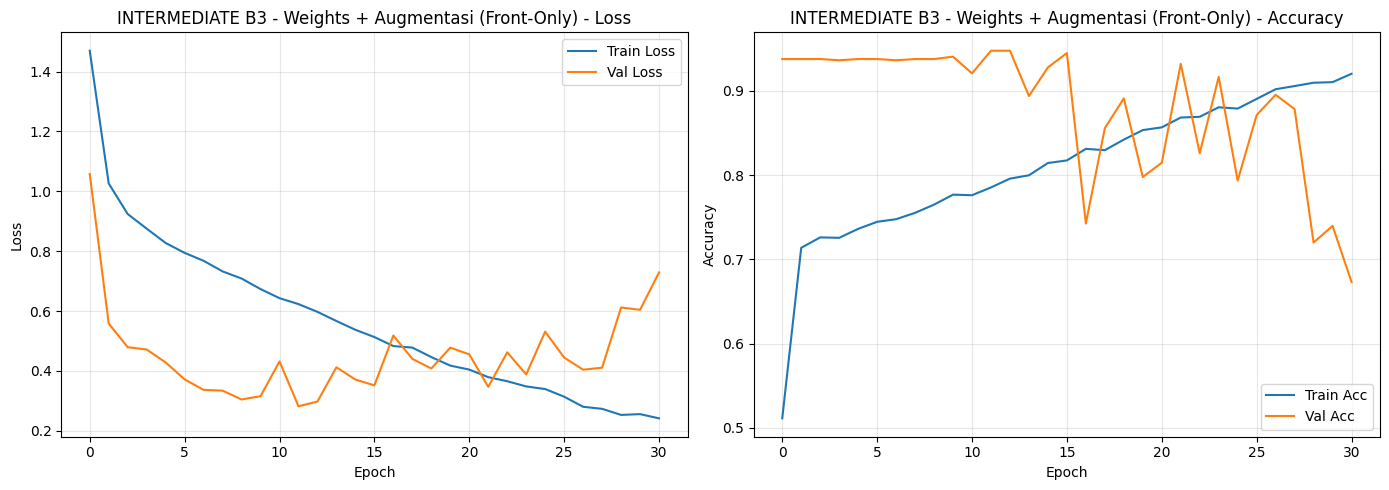

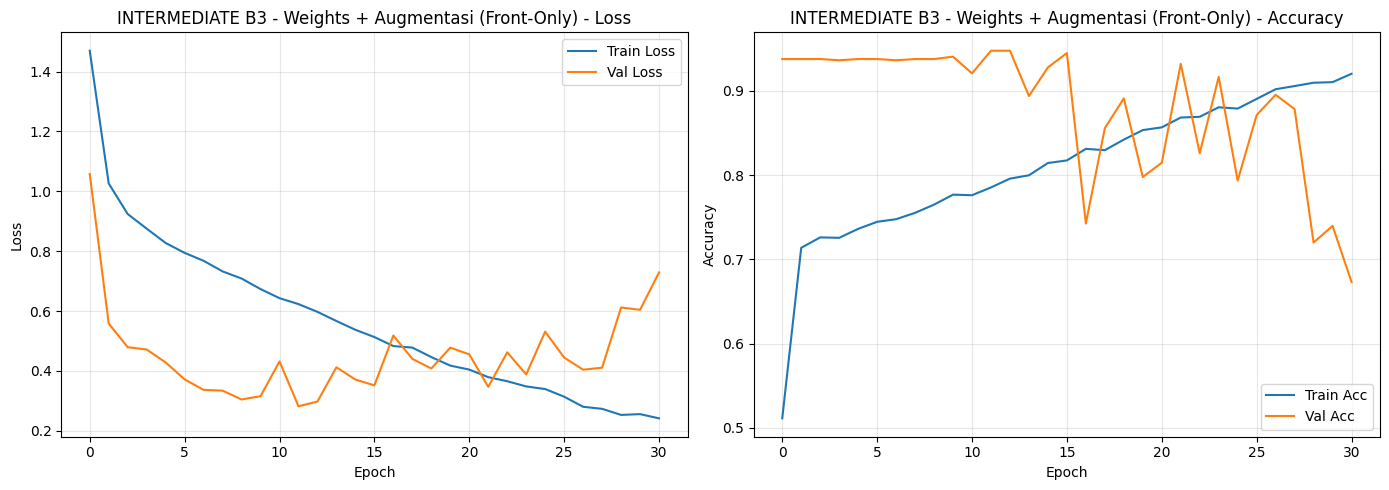

In [8]:
# B3: Weights + Augmentasi
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")
criterion = nn.CrossEntropyLoss(weight=weights_aug)

model = IntermediateFusion(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining INTERMEDIATE B3 - Weights + Augmentasi (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader_aug, val_loader, criterion, optimizer, scheduler,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_b3.pth"))

plot_training_history(history, "INTERMEDIATE B3 - Weights + Augmentasi (Front-Only)")

EVALUASI B3 - WEIGHTS + AUGMENTASI


Test Loss: 0.4457
Test Accuracy: 0.8571
Test Macro F1: 0.1350
Test Weighted F1: 0.8764

Classification Report:
              precision    recall  f1-score   support

     neutral       0.95      0.90      0.92       981
       happy       0.00      0.00      0.00        10
         sad       0.01      0.03      0.02        29
       angry       0.00      0.00      0.00        10
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         2

    accuracy                           0.86      1036
   macro avg       0.14      0.13      0.14      1036
weighted avg       0.90      0.86      0.88      1036



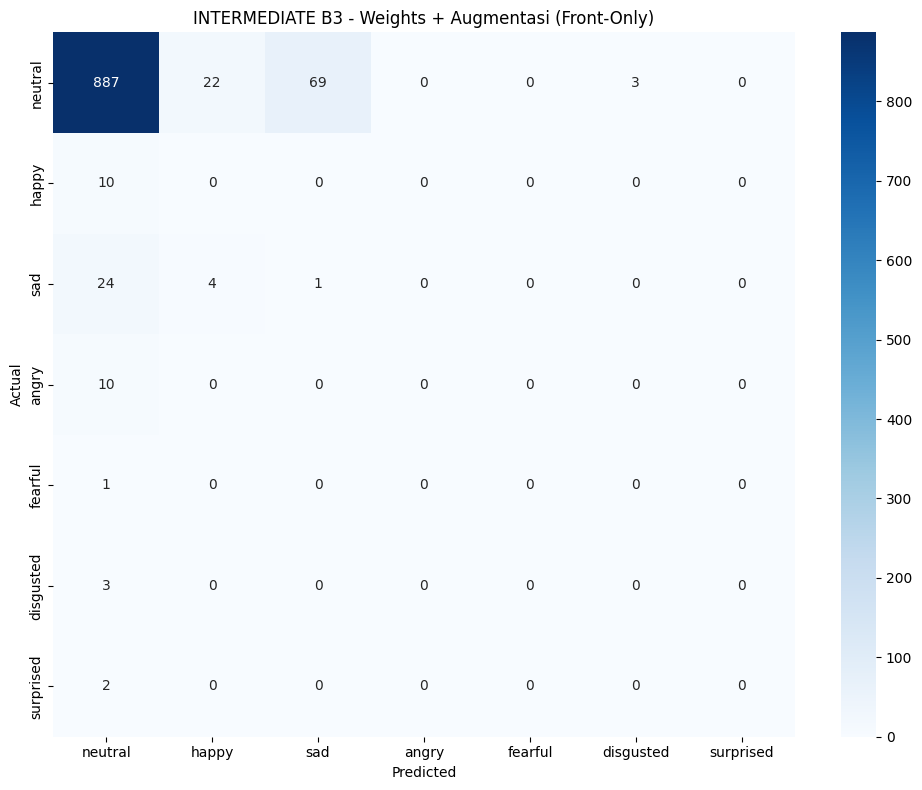

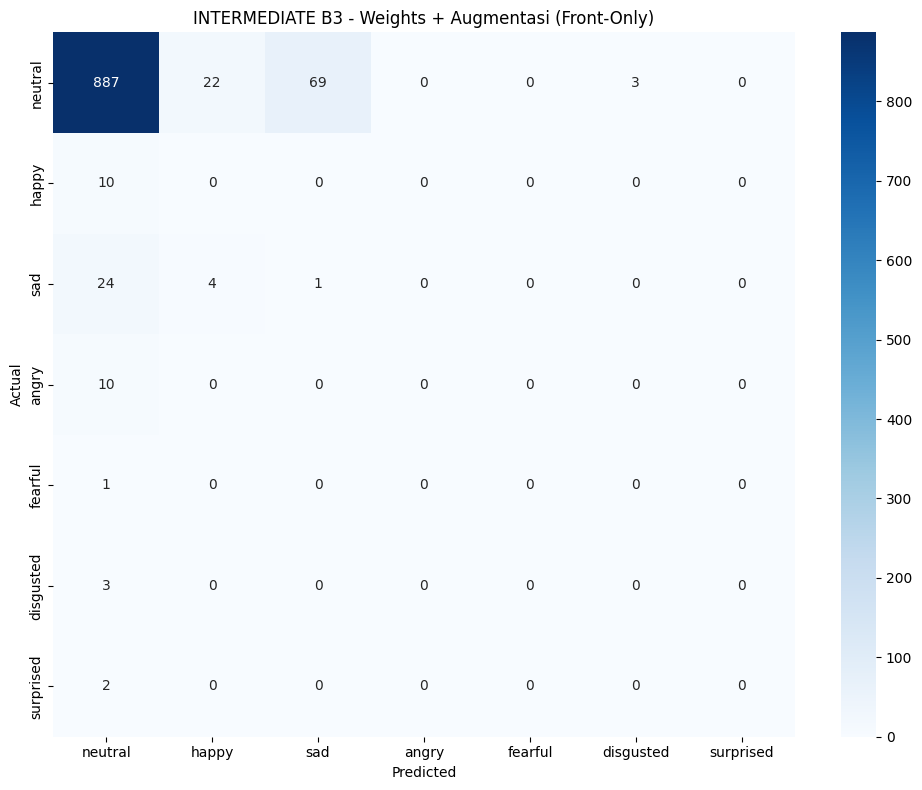

In [9]:
# Evaluate B3
model.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_b3.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B3 - WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model, test_loader, criterion, device, "fusion", EMOTIONS)
plot_confusion_matrix(results_b3["confusion_matrix"], "INTERMEDIATE B3 - Weights + Augmentasi (Front-Only)", EMOTIONS)

## Perbandingan 3 Skenario

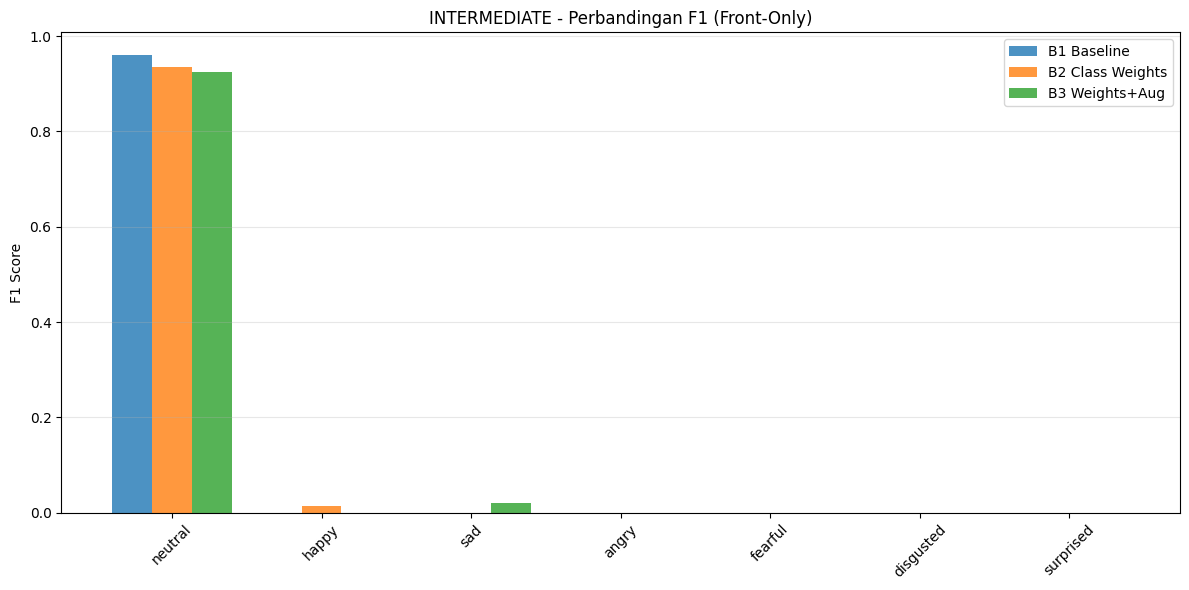

RINGKASAN INTERMEDIATE FRONT-ONLY
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.9141     0.1371       0.9090
B2 Class Weights              0.8494     0.1355       0.8851
B3 Weights+Aug                0.8571     0.1350       0.8764

Saved to /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/7class/intermediate_results.json


In [10]:
# Perbandingan
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "INTERMEDIATE - Perbandingan F1 (Front-Only)")

print("=" * 70)
print("RINGKASAN INTERMEDIATE FRONT-ONLY")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

results_save = {}
for name, r in all_results.items():
    results_save[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "intermediate_results.json", "w") as f:
    json.dump(results_save, f, indent=2)
print(f"\nSaved to {OUTPUT_DIR / 'intermediate_results.json'}")